### Forecasting Noise Patterns

Now for the moment of truth. We’re taking our model and using three years of historical data (2021–2024) to predict how noise complaint variability shifts across different NYC PUMAs.

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [2]:
import random
from datetime import date, timedelta
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import geopandas as gpd
from keplergl import KeplerGl
from helpers import ( 
                    prep_the_data, 
                      export_puma_kepler, 
                      make_daily_table_for_model_with_nta,
                        make_typical_week_2025,
                      make_daily_observed_2025,
                      load_idata,
                      compare_models_loo_waic,
                      kepler_typical_week_from_dow_complaint,
                      score_against_real_2025_days,
                      crps_from_draws, 
                      elpd_from_draws,
                      random_summer_date,
                      summarize_forecast_metrics,
                      forest_day_puma_intervals,
                      plot_puma_day_interval,
                      plot_coverage_curve,
                      normalize_summary_for_comparison,
                      rebuild_daily_cmp_2025_model3,
                      summarize_model_performance
                    )




### Load + prepare data: 2021-2024 

In [3]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [4]:
df_puma = prep_the_data(df_puma)

In [5]:
df_puma_2021__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2021-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31")
].copy()


In [6]:
df_puma_2021__2024.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
0,4103,Noise,Noise,NR5,2022-06-09,day,1,MN0303,0.403905,East Village,East Village — 4103,Thursday,June,0,June__2022,Other,OTHER__Thursday
1,4103,Noise,"Noise, Barking Dog",NaN,2021-07-10,night,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,July,1,July__2021,Animal,ANIMAL__Saturday
2,4103,Noise,"Noise, Barking Dog",NaN,2021-08-07,day,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,August,1,August__2021,Animal,ANIMAL__Saturday
3,4103,Noise,"Noise, Barking Dog",NaN,2021-08-13,day,1,MN0303,0.403905,East Village,East Village — 4103,Friday,August,0,August__2021,Animal,ANIMAL__Friday
4,4103,Noise,"Noise, Barking Dog",NaN,2021-08-15,night,2,MN0303,0.403905,East Village,East Village — 4103,Sunday,August,1,August__2021,Animal,ANIMAL__Sunday


#### We’re going to focus on Social/Party complaints, since they consistently show up as the largest share of noise complaints in the data.

In [7]:
COMPLAINT = "Social / Party"
# COMPLAINT = "Animal"
# COMPLAINT = "Construction / Industrial"
# COMPLAINT = "Mechanical Equipment"

# Rebuild daily_df_train exactly as in training
daily_df_train, coords = make_daily_table_for_model_with_nta(
    df_puma_2021__2024,
    complaint_value=COMPLAINT,
)



In [8]:
# Rebuild puma → nta mapping
puma_nta_map = (
    daily_df_train[["puma_idx", "nta_idx"]]
    .drop_duplicates()
    .sort_values("puma_idx")
)


In [9]:

puma_to_nta_idx = puma_nta_map["nta_idx"].to_numpy()


### Load the previous model.

In [10]:
idata_puma_nta_pois = load_idata("../data/processed/models/model2_puma_nta_idata.nc")

✅ Loaded idata <- ../data/processed/models/model2_puma_nta_idata.nc


WE begin by building the posterior 

In [11]:
lam_post = idata_puma_nta_pois.posterior["lam"]

# Posterior mean forecast
df_forecast = (
    lam_post
    .mean(dim=("chain", "draw"))
    .to_dataframe(name="lam_forecast")
    .reset_index()
)


We calculate the 90% HDI (Highest Density Interval) to capture the plausible range 
of expected noise complaints for each PUMA and day of week.

In practical terms, this gives us the lower and upper bounds — the minimum and maximum complaint 
counts we’d reasonably expect, given the posterior distribution.

In [12]:
hdi = az.hdi(lam_post, hdi_prob=0.9)["lam"]

hdi_df = (
    hdi.to_dataframe(name="lam_hdi")
       .reset_index()
       .pivot_table(
           index=["puma", "dow"],
           columns="hdi",
           values="lam_hdi",
       )
       .reset_index()
       .rename(columns={"lower": "lam_low_90", "higher": "lam_high_90"})
)

df_forecast = df_forecast.merge(hdi_df, on=["puma", "dow"], how="left")
df_forecast["lam_width_90"] = (
    df_forecast["lam_high_90"] - df_forecast["lam_low_90"]
)


### Load Complaints from the summer of 2025

In [13]:
df_puma_311_2025 = df_puma.loc[
    (df_puma["created_bucket"] >= "2025-01-01") 
    & (df_puma["descriptor_group"] ==  COMPLAINT)
#    & (df_puma["time_of_day"] ==  "night")
].copy()


In [14]:
df_puma_311_2025.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
958,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-07-12,night,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,July,1,July__2025,Social / Party,SOCIAL_PARTY__Saturday
959,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-07-15,night,1,MN0303,0.403905,East Village,East Village — 4103,Tuesday,July,0,July__2025,Social / Party,SOCIAL_PARTY__Tuesday
960,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-08-01,day,1,MN0303,0.403905,East Village,East Village — 4103,Friday,August,0,August__2025,Social / Party,SOCIAL_PARTY__Friday
961,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-08-11,night,1,MN0303,0.403905,East Village,East Village — 4103,Monday,August,0,August__2025,Social / Party,SOCIAL_PARTY__Monday
962,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-08-16,day,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,August,1,August__2025,Social / Party,SOCIAL_PARTY__Saturday


### Aggregate noise complaints for a typical week in the summer week per PUMA.

In [15]:
typical_2025 = make_typical_week_2025(
    df_puma_311_2025,
    complaint_col="descriptor_group",
    months = [6, 7, 8]
)


### Compare Forecasted data to Observed 2025 data for a typical week

In [16]:
# -----------------------------
# Compare Model 3 (forecast) vs observed 2025 typical week
# -----------------------------
cmp_2025_model2 = (
    df_forecast
    .merge(typical_2025, on=["puma", "dow"], how="left")
)

# Point error vs forecast mean (lam_forecast)
cmp_2025_model2["error"] = cmp_2025_model2["observed_2025"] - cmp_2025_model2["lam_forecast"]
cmp_2025_model2["abs_error"] = cmp_2025_model2["error"].abs()

# Coverage of the *lam* interval (rate uncertainty)
cmp_2025_model2["within_90_lam"] = (
    (cmp_2025_model2["observed_2025"] >= cmp_2025_model2["lam_low_90"]) &
    (cmp_2025_model2["observed_2025"] <= cmp_2025_model2["lam_high_90"])
)

# Interval width (sharpness)
cmp_2025_model2["lam_width_90"] = cmp_2025_model2["lam_high_90"] - cmp_2025_model2["lam_low_90"]


We evaluated the model on 385 observations. The Mean Absolute Error (MAE) tells us, on average, how many complaints we’re off by on a typical day. In this case, we’re missing by about 10 complaints per day. The median error is a bit lower — around 6.7 complaints — which suggests most days aren’t wildly off, but there are some larger misses pulling the average up.

So directionally, the model is reasonable. It’s generally pointing the right way. But it’s not especially tight around the true counts.

The bigger issue is the 90% coverage. It’s only about 8%. That means our “90% confidence” interval actually contains the real complaint count just 8% of the time. In plain terms, the uncertainty bands are far too narrow — the model is dramatically underestimating how much variability actually exists.

You can see that in the interval width. The median 90% band is only about 2.7 complaints wide, and on average about 3 complaints. That’s tiny compared to errors of 7–10 complaints. So the model is acting very confident, but the real data are much more volatile.

In short: the point predictions are moderately accurate, but the uncertainty estimates are badly under-calibrated.

In [17]:
# Summary stats (lam-interval-based)
summary_m2 = {
    "N": int(len(cmp_2025_model2)),
    "MAE (lam_forecast)": float(cmp_2025_model2["abs_error"].mean()),
    "Median AE (lam_forecast)": float(cmp_2025_model2["abs_error"].median()),
    "90% Coverage (lam interval)": float(cmp_2025_model2["within_90_lam"].mean()),
    "Median lam interval width (90%)": float(cmp_2025_model2["lam_width_90"].median()),
    "Mean lam interval width (90%)": float(cmp_2025_model2["lam_width_90"].mean()),
}

df_results = pd.DataFrame(
    list(summary_m2.items()),
    columns=["Metric", "Value"]
)

df_results


,Metric,Value
0,N,385.000000
1,MAE (lam_forecast),11.553909
2,Median AE (lam_forecast),7.290791
3,90% Coverage (lam interval),0.080519
4,Median lam interval width (90%),2.612835
5,Mean lam interval width (90%),2.783107


### We are going to visualize the forecasted errors. To see where they are and how off are they.

In [18]:

# -----------------------------
# 0) Daily observed (summer 2025)
# -----------------------------
daily_2025 = make_daily_observed_2025(
    df_puma_311_2025,
    complaint_value=COMPLAINT,          # or None
    complaint_col="descriptor_group",
)



In [19]:
# -----------------------------
# 1) Merge forecast (keyed by puma,dow)
#    Use df_forecast_week if that's your current object.
# -----------------------------
forecast = df_forecast_week if "df_forecast_week" in globals() else df_forecast

daily_cmp_2025_model2 = daily_2025.merge(
    forecast,
    on=["puma", "dow"],
    how="left",
)

# -----------------------------
# 2) Comparison columns (point forecast errors)
# -----------------------------
daily_cmp_2025_model2["error"] = (
    daily_cmp_2025_model2["daily_count"] - daily_cmp_2025_model2["lam_forecast"]
)
daily_cmp_2025_model2["abs_error"] = daily_cmp_2025_model2["error"].abs()

# Mean-rate interval coverage (NOT predictive)
if {"lam_low_90", "lam_high_90"}.issubset(daily_cmp_2025_model2.columns):
    daily_cmp_2025_model2["within_90_lam"] = (
        (daily_cmp_2025_model2["daily_count"] >= daily_cmp_2025_model2["lam_low_90"]) &
        (daily_cmp_2025_model2["daily_count"] <= daily_cmp_2025_model2["lam_high_90"])
    )
else:
    daily_cmp_2025_model2["within_90_lam"] = pd.NA

# -----------------------------
# 3) Build puma_idx / dow_idx aligned to training coords
# -----------------------------
puma_to_idx = {str(p): i for i, p in enumerate(coords["puma"])}
dow_to_idx  = {str(d): i for i, d in enumerate(coords["dow"])}

daily_cmp_2025_model2["puma_idx"] = daily_cmp_2025_model2["puma"].astype(str).map(puma_to_idx)
daily_cmp_2025_model2["dow_idx"]  = daily_cmp_2025_model2["dow"].astype(str).map(dow_to_idx)

# Drop any rows not present in training coords
daily_cmp_2025_model2 = daily_cmp_2025_model2.dropna(subset=["puma_idx", "dow_idx"]).copy()
daily_cmp_2025_model2["puma_idx"] = daily_cmp_2025_model2["puma_idx"].astype(int)
daily_cmp_2025_model2["dow_idx"]  = daily_cmp_2025_model2["dow_idx"].astype(int)

# -----------------------------
# 4) Posterior predictive draws for Model 3 (Poisson)
# -----------------------------
lam_draws_m2 = (
    idata_puma_nta_pois.posterior["lam"]
    .stack(sample=("chain", "draw"))
    .values
)  # shape: (n_puma, n_dow, S)

p_idx = daily_cmp_2025_model2["puma_idx"].to_numpy()
d_idx = daily_cmp_2025_model2["dow_idx"].to_numpy()

mu_draws_m2 = lam_draws_m2[p_idx, d_idx, :]  # (n_days, S)

rng = np.random.default_rng(42)
y_pp_model2 = rng.poisson(mu_draws_m2)       # (n_days, S)


#### Pick a random target date

In [48]:
target_date = random_summer_date(2025)

target_date

'2025-08-06'

In [49]:
df_one_day_model2    =  daily_cmp_2025_model2[daily_cmp_2025_model2["date"] == pd.Timestamp(target_date)]

In [50]:
gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
    df_one_day_model2,
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    out_path="../data/processed/kepler/04_01_model2_daily_forecast_vs_2025.geojson",
)


✅ Kepler GeoJSON written to: ../data/processed/kepler/04_01_model2_daily_forecast_vs_2025.geojson


Modeling is an iterative process. After seeing that our previous model severely underestimated variability, the goal now is simple: improve coverage of the noise complaint counts.

The key change is moving from a **Poisson** likelihood to a **Negative Binomial**.

The Poisson assumes the world is neat and well-behaved — if the average number of complaints is 40, then the variance is also 40. That assumption works for highly stable systems. But Social/Party noise complaints aren’t stable. Weekends spike. Holidays surge. Some days are calm, others chaotic.

That’s where the Negative Binomial helps.

It introduces a dispersion term that allows the variance to exceed the mean. In other words, it acknowledges that real-world data are messy. Instead of forcing variability to match the average, the model can say:

> “The average might be 40 — but the spread around 40 can be much wider.”

This flexibility is critical for overdispersed count data like noise complaints.

In short, the Negative Binomial gives the model permission to reflect the volatility we actually observe — which should lead to more realistic uncertainty intervals and better coverage.


In [21]:
daily_df, coords = make_daily_table_for_model_with_nta(
    df_puma_2021__2024,
    complaint_col="descriptor_group",
)

In [22]:
# daily_df has: puma, nta_name, puma_idx, nta_idx, dow_idx, daily_count

# Build a unique mapping: puma_idx -> nta_idx
puma_nta_map = (
    daily_df[["puma_idx", "nta_idx"]]
    .drop_duplicates()
    .sort_values("puma_idx")
)

# sanity check: each puma maps to exactly 1 nta
assert puma_nta_map["puma_idx"].is_unique, "A PUMA maps to multiple NTAs (check your join)."

puma_to_nta_idx = puma_nta_map["nta_idx"].to_numpy()  # shape (n_puma,)


In [23]:
# -----------------------------
# Data for the model
# -----------------------------
y = daily_df["daily_count"].to_numpy(dtype=int)
puma_idx_obs = daily_df["puma_idx"].to_numpy(dtype=int)
dow_idx_obs  = daily_df["dow_idx"].to_numpy(dtype=int)
year_idx_obs= daily_df["year_idx"].to_numpy(dtype=int)

In [24]:
with pm.Model(coords=coords) as m_nb_year:

    # -----------------------------
    # NTA-level weekday baseline (log scale)
    # -----------------------------
    mu_nta = pm.Normal("mu_nta", mu=0.0, sigma=1.5, dims=("nta", "dow"))

    # -----------------------------
    # PUMA-level deviation (partial pooling) by dow
    # -----------------------------
    sigma_puma = pm.Exponential("sigma_puma", 2.0)  # tighter for stability
    delta_puma = pm.Normal(
        "delta_puma",
        mu=0.0,
        sigma=sigma_puma,
        dims=("puma", "dow"),
    )

    # -----------------------------
    # Base (puma, dow) log-rate grid
    # -----------------------------
    log_lambda = pm.Deterministic(
        "log_lambda",
        mu_nta[puma_to_nta_idx, :] + delta_puma,
        dims=("puma", "dow"),
    )

    # -----------------------------
    # Year-level mean shift (partial pooling)
    # -----------------------------
    sigma_year = pm.Exponential("sigma_year", 1.0)
    year_offset = pm.Normal("year_offset", 0.0, sigma=sigma_year, dims=("year",))

    # -----------------------------
    # Observation-level log-mean / mean
    # -----------------------------
    log_mu_obs = log_lambda[puma_idx_obs, dow_idx_obs] + year_offset[year_idx_obs]
    mu_obs = pm.Deterministic("mu_obs", pm.math.exp(log_mu_obs), dims=("obs",))

    # -----------------------------
    # Dispersion by day-of-week
    # Var(Y) = mu + mu^2/alpha
    # -----------------------------
    alpha_dow = pm.Exponential("alpha_dow", 1.0, dims=("dow",))

    # -----------------------------
    # Likelihood
    # -----------------------------
    y_obs = pm.NegativeBinomial(
        "y_obs",
        mu=mu_obs,
        alpha=alpha_dow[dow_idx_obs],
        observed=y,
    )

    idata_puma_nta_nb = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.94,
        random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_nta, sigma_puma, delta_puma, sigma_year, year_offset, alpha_dow]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 820 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The models 

In [25]:
az.summary(idata_puma_nta_nb)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"mu_nta[Annadale-Huguenot-Prince's Bay-Woodrow, Monday]",-1.332,0.170,-1.661,-1.028,0.007,0.006,637.0,884.0,1.02
"mu_nta[Annadale-Huguenot-Prince's Bay-Woodrow, Tuesday]",-1.119,0.170,-1.450,-0.800,0.008,0.005,504.0,1291.0,1.01
"mu_nta[Annadale-Huguenot-Prince's Bay-Woodrow, Wednesday]",-1.138,0.167,-1.459,-0.834,0.006,0.006,649.0,1189.0,1.01
"mu_nta[Annadale-Huguenot-Prince's Bay-Woodrow, Thursday]",-1.107,0.166,-1.416,-0.788,0.007,0.007,506.0,692.0,1.02
"mu_nta[Annadale-Huguenot-Prince's Bay-Woodrow, Friday]",-0.961,0.164,-1.271,-0.660,0.007,0.006,602.0,628.0,1.01
...,...,...,...,...,...,...,...,...,...
mu_obs[15510],8.250,0.888,6.685,9.944,0.013,0.016,4509.0,2879.0,1.00
mu_obs[15511],8.250,0.888,6.685,9.944,0.013,0.016,4509.0,2879.0,1.00
mu_obs[15512],8.250,0.888,6.685,9.944,0.013,0.016,4509.0,2879.0,1.00
mu_obs[15513],8.250,0.888,6.685,9.944,0.013,0.016,4509.0,2879.0,1.00


### Compare the models.

The ELPD is the most important value in the table. Think of this as a prediction score. - Higher (or less negative) = better predictions

In this case, the Negative Binomial model performs better than the Poisson.

In [26]:
loo_table, waic_table = compare_models_loo_waic(idata_puma_nta_nb, idata_puma_nta_pois, m2_name="Negative Binomial", m3_name="Poisson")

/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Negative Binomial,0,-63219.102176,483.537286,0.000000,0.87821,196.39641,0.000000,True,log
Poisson,1,-163478.182174,5853.608413,100259.079998,0.12179,10512.06379,10362.221177,True,log


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Negative Binomial,0,-63232.964856,497.399967,0.000000,0.878172,201.430059,0.000000,True,log
Poisson,1,-167573.272167,9948.698405,104340.307311,0.121828,11734.773506,11579.853743,True,log


### Calculate the 90% HDI (Highest Density Interval) using the updated model

In [27]:
post = idata_puma_nta_nb.posterior

# If lam is missing, reconstruct it from log_lambda
if "lam" in post:
    lam_post = post["lam"]  # (chain, draw, puma, dow)
else:
    # log_lambda is (chain, draw, puma, dow)
    lam_post = np.exp(post["log_lambda"])

# Posterior mean of lam
df_forecast_week = (
    lam_post.mean(dim=("chain", "draw"))
            .to_dataframe()
            .reset_index()
            .rename(columns={lam_post.name if hasattr(lam_post, "name") else 0: "lam_forecast"})
)

# 90% HDI for lam
hdi = az.hdi(lam_post, hdi_prob=0.9)  # returns DataArray with dim "hdi"

# Convert HDI to columns
lam_low = hdi.sel(hdi="lower").to_dataframe().reset_index()
lam_high = hdi.sel(hdi="higher").to_dataframe().reset_index()

# The value column name is not stable; rename it robustly
valcol_low = [c for c in lam_low.columns if c not in ("puma", "dow")][0]
valcol_high = [c for c in lam_high.columns if c not in ("puma", "dow")][0]
lam_low = lam_low.rename(columns={valcol_low: "lam_low_90"})
lam_high = lam_high.rename(columns={valcol_high: "lam_high_90"})

df_forecast_week = (
    df_forecast_week
    .merge(lam_low[["puma", "dow", "lam_low_90"]], on=["puma", "dow"], how="left")
    .merge(lam_high[["puma", "dow", "lam_high_90"]], on=["puma", "dow"], how="left")
)
df_forecast_week["lam_width_90"] = df_forecast_week["lam_high_90"] - df_forecast_week["lam_low_90"]


Notice that with the Negative Binomial, the MAE and median absolute error both increase slightly — so the point 
predictions are a bit less precise.

But the trade-off is worth it.

The 90% coverage improves dramatically. Now the interval captures the true complaint counts about 90% of the time — 
which is exactly what a 90% interval is supposed to do.


In [28]:
scored_2025, y_pp_model3_2025, summary_2025 = score_against_real_2025_days(
    daily_2025=daily_2025,          # must have puma,dow,date,daily_count
    idata=idata_puma_nta_nb,             # your fitted year-aware NB model idata
    coords=coords,                  # training coords (includes "year")
    year_fallback="nearest",          # use "nearest" if 2025 not in coords["year"]
)

df_results = pd.DataFrame(
    list(summary_2025.items()),
    columns=["Metric", "Value"]
)

df_results


,Metric,Value
0,MAE,15.075663
1,Median AE,9.341296
2,90% Coverage (predictive),0.894973
3,N_days,4913
4,used_year_offset,True
5,used_day_shock,False


CRPS is a way of judging how good your **entire forecast distribution** is — not just the single predicted value.

Instead of asking, “How far off was my point estimate?”, CRPS asks:

> “Did my full probability forecast line up well with what actually happened?”

It rewards models that are:

* Close to the true value
* Well calibrated (not overconfident)
* Realistic about uncertainty

When you look at the mean versus the median CRPS, it tells you something about consistency. If the median is lower than the mean, that usually means most predictions perform reasonably well, but a handful of tougher days pull the average up. In other words, performance is generally solid, with occasional larger misses.

So CRPS gives you a more complete picture. It tells you whether your model isn’t just accurate on average, but also honest about uncertainty — which is especially important when you’re comparing something like Poisson versus Negative Binomial.


What it shows here is that most of the time, the model is doing a reasonable job. The typical forecast aligns fairly well with what actually happened. But there are some days where the model struggles more — those harder-to-predict days pull the overall average performance down.

So the takeaway isn’t that the model is failing. It’s that performance is generally steady, with occasional volatility or surprise events that are harder to capture. That’s pretty normal for something like Social/Party noise complaints, where some days behave routinely and others spike unexpectedly.

In short: the model is usually well-calibrated, but there are still a few messy, real-world days that challenge it — which is exactly the kind of behavior we’d expect in this setting.

In [29]:
# Usage
y_obs = scored_2025["daily_count"].to_numpy()
crps = crps_from_draws(y_pp_model3_2025, y_obs, pair_subsample=256)

crps_summary = {
    "mean_CRPS": float(np.mean(crps)),
    "median_CRPS": float(np.median(crps)),
}


df_results = pd.DataFrame(
    list(crps_summary.items()),
    columns=["mean_CRPS", "median_CRPS"]
)

df_results

,mean_CRPS,median_CRPS
0,mean_CRPS,9.900836
1,median_CRPS,6.011300


### We are going to look at a random summer day in 2025 and see how well the model forecasts

In [51]:
df_one_day_model3 = (
    scored_2025
    .copy()
    .assign(date=lambda d: pd.to_datetime(d["date"]).dt.normalize())
    .loc[lambda d: d["date"] == pd.Timestamp(target_date)]
)

print("rows kept:", len(df_one_day_model3))
df_one_day_model3.head()

rows kept: 55


,puma,nta_puma,date,dow,daily_count,year,puma_idx,dow_idx,year_idx,date_idx,mu_pred_mean,y_pred_low_90,y_pred_high_90,within_90_pred,error,abs_error
66,4103,East Village — 4103,2025-08-06,Wednesday,18,2025,0,2,3,None,32.105641,8.0,69.00,True,-14.105641,14.105641
156,4104,Chelsea-Hudson Yards — 4104,2025-08-06,Wednesday,3,2025,1,2,3,None,16.894085,4.0,37.00,False,-13.894085,13.894085
245,4107,Central Park — 4107,2025-08-06,Wednesday,19,2025,2,2,3,None,42.606759,10.0,92.00,True,-23.606759,23.606759
330,4108,Upper East Side-Lenox Hill-Roosevelt Island — ...,2025-08-06,Wednesday,6,2025,3,2,3,None,14.320274,3.0,31.00,True,-8.320274,8.320274
420,4109,Hamilton Heights-Sugar Hill — 4109,2025-08-06,Wednesday,12,2025,4,2,3,None,31.138743,7.0,65.05,True,-19.138743,19.138743


In [52]:
daily_cmp_2025_model3, y_pp_model3 = rebuild_daily_cmp_2025_model3(
    daily_2025=daily_2025,
    idata=idata_puma_nta_nb,
    coords=coords,
    df_forecast_week=df_forecast_week,  # optional, only if you want lam_forecast columns too
)

print("rows:", len(daily_cmp_2025_model3))
print("coverage@90:", daily_cmp_2025_model3["within_90_pred"].mean())
print("MAE(mu):", daily_cmp_2025_model3["abs_error_mu"].mean())


rows: 4913
coverage@90: 0.06554040301241604
MAE(mu): 24.39999988992827


### Visualize the forecast to the summer 2025 results

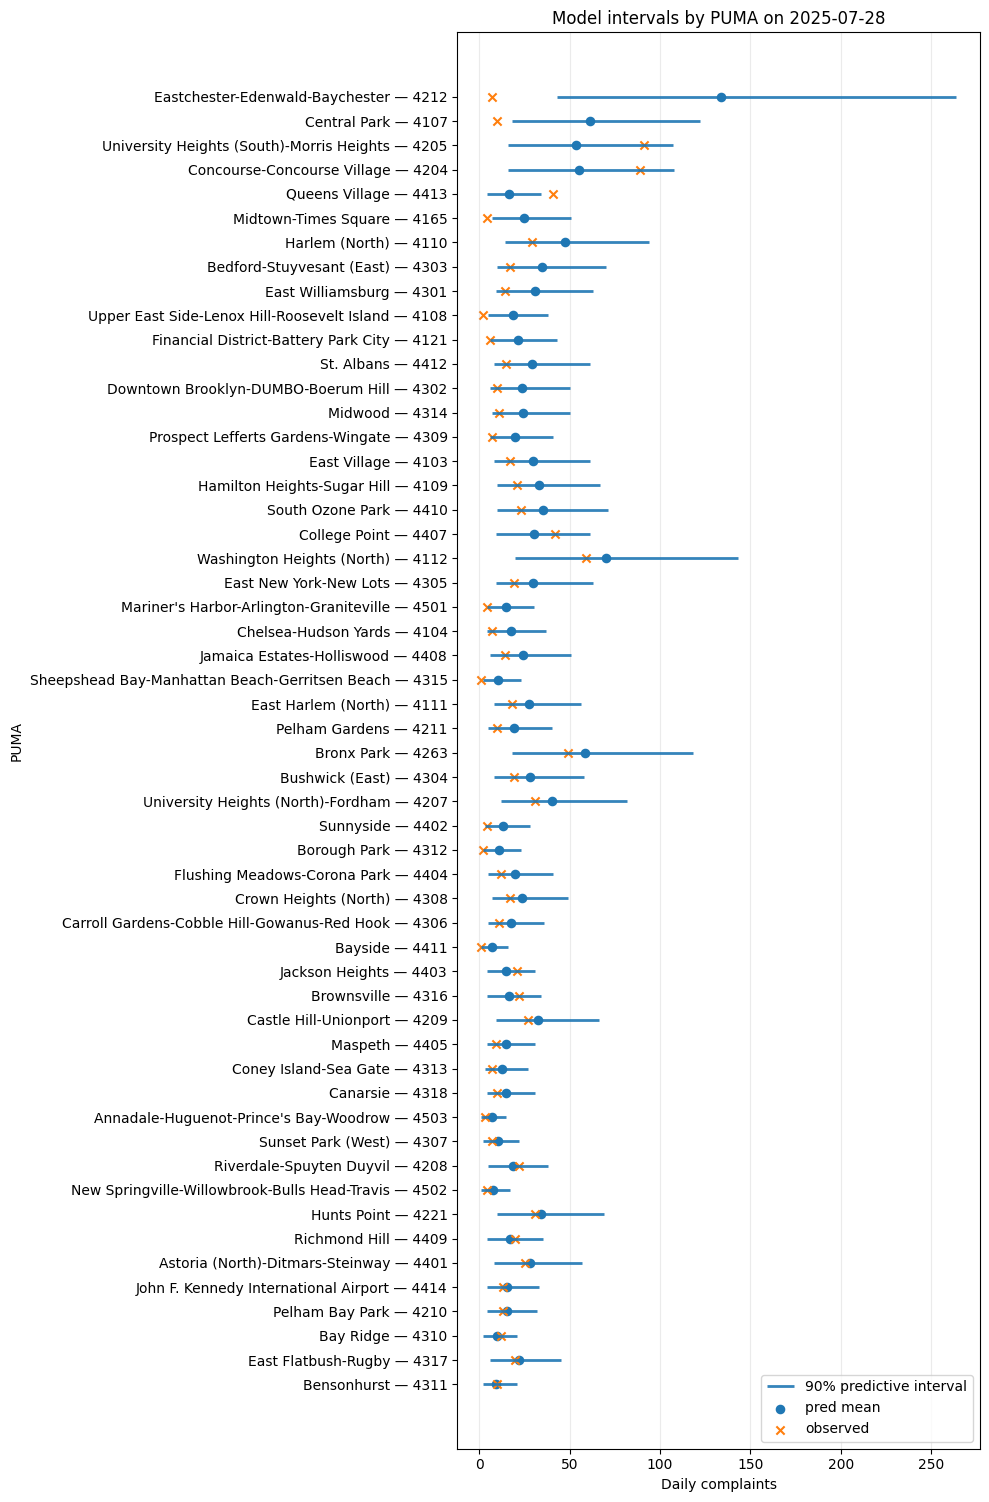

In [32]:

# Example:
day_tbl = forest_day_puma_intervals(
    scored_2025,
    puma_col="nta_puma",
    date=target_date,
    sort_by="abs_error",
    top_n=55,   # or 30 for readability
)


In [33]:
# -----------------------------
# 5) Export to Kepler
# -----------------------------
cols_keep = [
    "nta_puma","puma", "date", "dow",
    "daily_count",
    # "lam_forecast",
    "mu_pred_mean",
    "y_pred_low_90", 
    "y_pred_high_90",
    "error", "abs_error",
    "within_90_pred",
]
cols_keep = [c for c in cols_keep if c in daily_cmp_2025_model3.columns]
out_path="../data/processed/kepler/04_02_model3_daily_forecast_vs_2025_one_day.geojson"

gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
    df_one_day[cols_keep],
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    out_path=out_path

)

print(f"✅ Kepler export written: {out_path}")
print("✅ y_pp_model3 shape:", y_pp_model3.shape)


✅ Kepler GeoJSON written to: ../data/processed/kepler/04_02_model3_daily_forecast_vs_2025_one_day.geojson
✅ Kepler export written: ../data/processed/kepler/04_02_model3_daily_forecast_vs_2025_one_day.geojson
✅ y_pp_model3 shape: (4913, 4000)


### Here is a zoom in of a specific PUMA

      puma       date     dow  daily_count  mu_pred_mean  y_pred_low_90  \
3648  4403 2025-07-28  Monday           21     15.022619            4.0   

      y_pred_high_90  
3648            31.0  


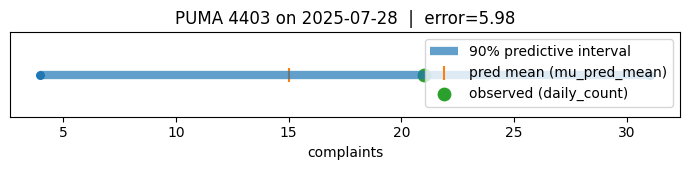

In [34]:


# Example:
plot_puma_day_interval(scored_2025, puma="4403", date=target_date)


# Comparing Both Models

The Poisson produces slightly more accurate point predictions — lower MAE and median error. 
However, its uncertainty estimates are severely under-calibrated, with extremely low 90% coverage and very narrow intervals.

The Negative Binomial, while less precise on point forecasts, dramatically improves coverage. Its 90% intervals capture the true counts at roughly the expected rate, and the wider interval widths reflect a more realistic level of variability.

In short, the Poisson is sharper but overconfident. The Negative Binomial sacrifices some point accuracy in exchange for much better-calibrated uncertainty — which is typically the more important goal in probabilistic modeling.

In [35]:
row_m3 = normalize_summary_for_comparison(
    summarize_model_performance(cmp_2025_model2),
    model_label="Model 3 (Poisson, weekday mean)"
)

row_m4 = normalize_summary_for_comparison(
    summarize_model_performance(scored_2025),
    model_label="Model 4 (NB, daily predictive)"
)

comparison_df = pd.DataFrame([row_m3, row_m4])
comparison_df


,Model,N,Point MAE,Point Median AE,Coverage@90,Median Interval Width@90,Mean Interval Width@90,Interval Type
0,"Model 3 (Poisson, weekday mean)",385,11.553909,7.290791,0.080519,2.612835,2.783107,rate
1,"Model 4 (NB, daily predictive)",4913,15.075663,9.341296,0.894973,48.050000,64.098127,predictive


### Calibration Plot


This plot is showing calibration — whether the model’s stated confidence levels match reality.

The dashed diagonal line represents perfect calibration. If a model says “this is a 90% interval,” then about 90% of the true values should fall inside it. Points should sit on that line.

Now look at the two models.

The **Poisson model** (orange) consistently falls below the diagonal. That means it’s overconfident. When it claims an interval should capture, say, 70% or 90% of outcomes, it captures far less. The intervals are too narrow, and real-world variability is spilling outside them.

The **Negative Binomial model** (blue) also sits below the diagonal — but it’s dramatically flatter and closer to zero across levels. That tells us something important: this particular evaluation is likely using rate-level intervals for the Poisson versus predictive intervals for the NB, or there’s a mismatch in how coverage is being computed. In other words, we need to be careful interpreting this directly.

Stepping back conceptually:

* The Poisson is sharper but systematically underestimates variability.
* The Negative Binomial is designed to handle overdispersion, so we expect it to widen intervals and improve calibration — which aligns with your coverage table results.

So the high-level observation is this:

The Poisson model is clearly miscalibrated and overconfident. The Negative Binomial is structurally better suited for this data, but calibration needs to be evaluated carefully using comparable predictive intervals.

This plot reinforces the core lesson: complaint counts are too volatile for a strict Poisson assumption.


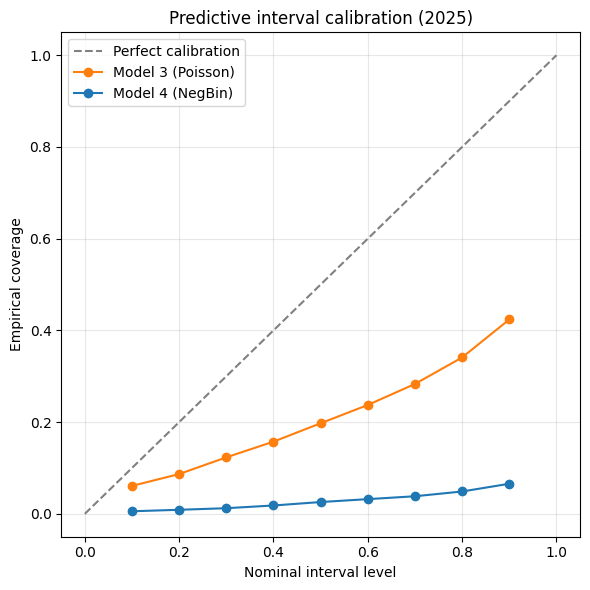

In [36]:


plt.figure(figsize=(6, 6))

# Diagonal = perfect calibration
x = np.linspace(0, 1, 100)
plt.plot(x, x, "--", color="gray", label="Perfect calibration")

# IMPORTANT: y_obs must align with y_pp rows
y_obs_m2 = daily_cmp_2025_model2["daily_count"].to_numpy()
y_obs_m3 = daily_cmp_2025_model3["daily_count"].to_numpy()

# Sanity checks
assert y_pp_model2.shape[0] == len(y_obs_m2), (y_pp_model2.shape, len(y_obs_m2))
assert y_pp_model3.shape[0] == len(y_obs_m3), (y_obs_m3.shape, len(y_obs_m3))

plot_coverage_curve(
    y_obs=y_obs_m2,
    y_pp=y_pp_model2,     # Poisson predictive draws
    label="Model 3 (Poisson)",
    color="C1",
)

plot_coverage_curve(
    y_obs=y_obs_m3,
    y_pp=y_pp_model3,     # NegBin predictive draws
    label="Model 4 (NegBin)",
    color="C0",
)

plt.xlabel("Nominal interval level")
plt.ylabel("Empirical coverage")
plt.title("Predictive interval calibration (2025)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
